In [1]:
import torch
from torch.autograd import grad
from scipy.io import savemat, loadmat


import pandas as pd
import seaborn as sns
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from chebyshev_utils import *
from GEOMLOSS import samples_loss
from tqdm import tqdm_notebook as tqdm
import os
from genesets import genesets
from genesets_exvivo import genesets_exvivo

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32768"

import scvelo as scv
import scanpy as sc
import anndata as ad

from TrajectoryNet.parse import parser
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import matplotlib as mpl
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })

2026-02-07 14:10:41.417792: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770491441.436170 2271597 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770491441.451488 2271597 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


cuda


In [2]:
device='cpu'

### Load train data

In [3]:
def load_data(path,nsamples,genes,time_str,cell_type_str):
    Ndim = len(genes);
    args = parser.parse_args(args=[])
    args.dataset = path
    adata = sc.read_h5ad(args.dataset)

    unique_times = adata.obs[str(time_str)].unique()
    nsnaps = len(unique_times); 
    samples = np.zeros((len(unique_times),nsamples,Ndim+1))

    cell_type_categories = list(adata.obs[str(cell_type_str)].cat.categories)
    cell_type_to_int = {ct: i for i, ct in enumerate(cell_type_categories)}
    ind_array = np.zeros((nsnaps, nsamples), dtype=int)

    print(cell_type_categories, cell_type_to_int)
    for k in range(0,len(unique_times)):
        time_point = unique_times[k] # Replace with actual time (e.g., "10h" or 10)
        cells_at_time = adata[adata.obs[str(time_str)] == time_point]
        cell_names = cells_at_time.obs_names.tolist()
        selected = np.arange(0,nsamples)

        expression_t0 = cells_at_time[:, genes].X
        expression_t0 = cells_at_time[:, genes].X
        
        expression_t0_numpy = expression_t0.toarray() if hasattr(expression_t0, "toarray") else np.array(expression_t0)
        print(" shape ", k, " : ", expression_t0_numpy.shape)

        randind = np.arange(0, len(cell_names))
        half = int(nsamples/1)
        for ll in range(0,1):
            np.random.shuffle(randind); 
            selected =  randind[0:half] # np.arange(0,nsamples)
            cell_types_k = cells_at_time.obs[str(cell_type_str)].iloc[selected].values
            ind_array[k, ll*half:(ll+1)*half] = [cell_type_to_int[ct] for ct in cell_types_k]
            samples[k,ll*half:(ll+1)*half,0:Ndim] = expression_t0_numpy[selected,:]
            samples[k,ll*half:(ll+1)*half,Ndim]   = unique_times[k]
            print(" time ", unique_times[k])

    return samples, unique_times, ind_array, adata.obs[str(cell_type_str)]

geneset_num = 7;
genes = genesets_exvivo[geneset_num] 
print(" genes being used ", genes)

nsamples = 6_000; 
path = '/mnt/home/vchardes/ceph/datasets/HSC_data/10XChromiumV3_10.1038_s41467-021-27159-x_10.5281_zenodo.5291737_exvivo.h5ad'
samples_full, tp, ind_array, cell_types = load_data(path,nsamples,genes,"day","cell_type")
print(samples_full.shape)

samples = samples_full[:,:,:] + 0;

Ndim = len(genes); nsnaps = samples.shape[0]; 
Dist = samples[:,:,:] + 0;
print(" samples shape ", samples.shape, ind_array.shape, Dist.shape)
print(cell_types)

 genes being used  ['gata1', 'fli1', 'klf1', 'gata2', 'gfi1', 'gfi1b', 'runx1', 'tal1', 'jun', 'spi1', 'zfpm1', 'lmo2', 'etv6', 'erg', 'cebpa', 'meis1', 'sall4', 'myc', 'foxo3', 'zbtb7a', 'nanog', 'nfe2', 'stat3', 'mef2c']
['Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2', 'Mk1', 'Mk2'] {'Ery1': 0, 'Ery2': 1, 'HSPC': 2, 'MPP1': 3, 'MPP2': 4, 'Mk1': 5, 'Mk2': 6}
 shape  0  :  (6203, 24)
 time  0
 shape  1  :  (9197, 24)
 time  2
 shape  2  :  (9789, 24)
 time  4
 shape  3  :  (7739, 24)
 time  6
 shape  4  :  (10387, 24)
 time  8
 shape  5  :  (10188, 24)
 time  11
(6, 6000, 25)
 samples shape  (6, 6000, 25) (6, 6000) (6, 6000, 25)
ED00:AAACTTGACGTACAx      HSPC
ED00:AAATGTTGTACGACx      HSPC
ED00:AAACCGTGTGGTACx      HSPC
ED00:AAATTGACTGTGGTx      HSPC
ED00:AACAATACAATGCCx      HSPC
                          ... 
MD11:TTTGTCAGTGTTCTTTx     Mk1
MD11:TTTGTCACAGAAGCACx     Mk1
MD11:TTTGTCAAGAAGGTGAx     Mk1
MD11:TTTGCGCGTAAACACAx     Mk1
MD11:TTTGGTTAGTCTTGCAx     Mk2
Name: cell_type, Length: 53503

### Index of the cell-types at the last time point

In [4]:
ind_Meg = np.where( (ind_array[-1,:]==6)   )[0] # 
ind_Ery = np.where(  (ind_array[-1,:]==1)   )[0] # 
ind_Eryp = np.where(  (ind_array[-3,:]==0)   )[0] # 
print(len(ind_Eryp), len(ind_Ery), len(ind_Meg))

1538 828 1976


### String of cell-type names, ordered based on the dictionary labels

In [5]:
cell_types = ['Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2', 'Mk1', 'Mk2']
print(cell_types)

['Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2', 'Mk1', 'Mk2']


### Cell-type evolution over days

In [6]:
for k in range(0, samples.shape[0]):
    store_num = np.zeros((len(cell_types),))
    for pp in range(0, len(cell_types)):
        ind = np.where(ind_array[k,:]==pp)[0]
        store_num[pp] = len(ind)
    print(cell_types[0], store_num[0], "   ", cell_types[1], store_num[1], "   ",  cell_types[2], store_num[2], "   ", 
          cell_types[3], store_num[3], "   ", cell_types[4], store_num[4], "   ", cell_types[5], store_num[5], "   ", cell_types[6], store_num[6])

ind_Ery2 = np.where( (ind_array[-1,]==1) | (ind_array[-1,]==0))[0]
Ery2 = samples[-1,ind_Ery2,:]
print(Ery2.shape)

ind_Mk2 = np.where( (ind_array[-1,]==6) | (ind_array[-1,]==5) )[0]
Mk2 = samples[-1,ind_Mk2,:]
print(Mk2.shape)

Ery1 3.0     Ery2 0.0     HSPC 5895.0     MPP1 30.0     MPP2 40.0     Mk1 12.0     Mk2 20.0
Ery1 2.0     Ery2 0.0     HSPC 2.0     MPP1 5126.0     MPP2 476.0     Mk1 389.0     Mk2 5.0
Ery1 1793.0     Ery2 177.0     HSPC 5.0     MPP1 1916.0     MPP2 841.0     Mk1 1233.0     Mk2 35.0
Ery1 1538.0     Ery2 749.0     HSPC 0.0     MPP1 973.0     MPP2 202.0     Mk1 2178.0     Mk2 360.0
Ery1 1206.0     Ery2 737.0     HSPC 1.0     MPP1 537.0     MPP2 56.0     Mk1 2318.0     Mk2 1145.0
Ery1 1071.0     Ery2 828.0     HSPC 1.0     MPP1 304.0     MPP2 29.0     Mk1 1791.0     Mk2 1976.0
(1899, 25)
(3767, 25)


### Load test data 

In [7]:
genes = genesets_exvivo[geneset_num] #['fli1', 'klf1', 'gata1', 'gata2', 'gfi1', 'runx1', 'tal1', 'jun','spi1', 'zfpm1', 'lmo2','etv6','erg','cebpa','meis1','sall4','myc','foxo3']
Ndim = len(genes);
nsamples = 16_000; 
path = '/mnt/home/vchardes/ceph/datasets/HSC_data/kaggle_multiome_RNA_new_cleaned.h5ad'
samples_test, tp_test, ind_array_test, cell_types_test = load_data(path,nsamples,genes,"day","cell_type")
cell_types_test = ['Bcell','Ery','Granu','HSPC','MEMP','Meg','Megp','Mono','MyP','Mast','Baso','Eos']

for k in range(0, samples_test.shape[0]):
    for pp in range(0, len(cell_types_test)):
        ind = np.where(ind_array_test[k,:]==pp)[0]
        print(cell_types_test[pp], len(ind))
    print("\n")

ind = np.where(ind_array_test[0,:]==3)[0]
HSC = samples_test[0,ind,:]
print(" HSPC shape ", HSC.shape)

ind = np.where(ind_array_test[0,:]==1)[0]
EryP = samples_test[0,ind,:]
print(" EryP ", EryP.shape)

['B cell', 'Erythroid cell', 'Granulocyte monocyte progenitor', 'HSPC', 'MEMP', 'Megakaryocyte', 'Megakaryocyte progenitor cell', 'Monocyte', 'Myeloid progenitor', 'Mast', 'Basophil', 'Eosinophil'] {'B cell': 0, 'Erythroid cell': 1, 'Granulocyte monocyte progenitor': 2, 'HSPC': 3, 'MEMP': 4, 'Megakaryocyte': 5, 'Megakaryocyte progenitor cell': 6, 'Monocyte': 7, 'Myeloid progenitor': 8, 'Mast': 9, 'Basophil': 10, 'Eosinophil': 11}
 shape  0  :  (28760, 24)
 time  2
 shape  1  :  (27303, 24)
 time  3
 shape  2  :  (35973, 24)
 time  4
 shape  3  :  (26866, 24)
 time  7
 shape  4  :  (16439, 24)
 time  10
Bcell 12
Ery 1692
Granu 936
HSPC 9975
MEMP 2749
Meg 0
Megp 48
Mono 104
MyP 358
Mast 75
Baso 39
Eos 12


Bcell 4
Ery 1915
Granu 1990
HSPC 8003
MEMP 2636
Meg 3
Megp 115
Mono 229
MyP 689
Mast 87
Baso 295
Eos 34


Bcell 2
Ery 3405
Granu 2844
HSPC 5286
MEMP 1657
Meg 10
Megp 490
Mono 256
MyP 1100
Mast 89
Baso 695
Eos 166


Bcell 1
Ery 2319
Granu 3555
HSPC 2098
MEMP 584
Meg 657
Megp 1753
Mono 1

In [8]:
def gradient_field(phi_,inp_):
    
    gradient = grad(outputs=phi_,inputs=inp_,
                      grad_outputs=torch.ones_like(phi_), 
                      create_graph=True)[0]

    return gradient

def simulate_inferrred_interpolation(drift_net, samples, tp, lx, nm, pert_flag=False, pert_ind=0, intrpl_flag=False):
    loss_fn = samples_loss.SamplesLoss("energy")
    drift_net.eval()

    K, Ndata, Ndim = samples.shape
    K = samples.shape[0]; Ndata = samples.shape[1];
    Ndim  = samples.shape[2]-1;

    init = torch.zeros((Ndata, Ndim + 1), device=device)
    init[:, :Ndim] = torch.tensor(samples[0, :, :Ndim], dtype=torch.float32, device=device)
    init[:, Ndim] = tp[0]  # start sim_time from tp[0]

    Xold = init.clone().detach()
    inf_dt = 0.01
    max_time = tp[-1]
    sim_time = tp[0]
    tp_idx = 0
    total_err = 0.0
    kappa = 0.1

    store_path = [];
    while sim_time <= max_time and tp_idx < K:
        with torch.no_grad():
            #if(nm=="Langevin"):
            if(nm=="Langevin" or nm=="Langevin_new"):
                drift = drift_net(Xold[:, :Ndim])
                noise = (1 ** 0.5)*torch.sqrt((drift + lx * Xold[:, :Ndim])) * (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)
                #noise = torch.sqrt(torch.relu(Xold[:, :Ndim])) * (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)
                Xnew = Xold.clone()
                Xnew[:, :Ndim] = Xold[:, :Ndim] + (drift - lx * Xold[:, :Ndim]) * inf_dt + noise
                if(pert_flag): Xnew[:,pert_ind] = 0;
                # Xnew[:,3] = 5;
            elif(nm=="Mult"):
                drift = drift_net(Xold[:, :Ndim])
                noise = torch.sqrt(torch.relu(Xold[:, :Ndim])) * (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)
                Xnew = Xold.clone()
                Xnew[:, :Ndim] = Xold[:, :Ndim] + (drift - lx * Xold[:, :Ndim]) * inf_dt + noise
                if(pert_flag): Xnew[:,pert_ind] = 0;
            elif(nm=="Additive"):
                drift = drift_net(Xold[:, :Ndim])
                noise =  (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)
                Xnew = Xold.clone()      
                Xnew[:, :Ndim] = Xold[:, :Ndim] + (drift - lx * Xold[:, :Ndim]) * inf_dt + noise
                if(pert_flag): Xnew[:,pert_ind] = 0;
            elif(nm=="ODE"):
                drift = drift_net(Xold[:, :Ndim])
                Xnew = Xold.clone()      
                Xnew[:, :Ndim] = Xold[:, :Ndim] + (drift - lx * Xold[:, :Ndim]) * inf_dt 
                if(pert_flag): Xnew[:,pert_ind] = 0;
            elif(nm=="pres"):
                noise =  (2.0 ** 0.5)*(inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=device)  
                with torch.enable_grad():
                    inp_ = Xold[:, 0:Ndim].clone()
                    inp_.requires_grad_()
                    phi = drift_net(inp_)
                    grad_drift  = gradient_field(phi, inp_)   
                    Xnew = Xold.clone()    
                    Xnew[:, :Ndim] = Xold[:, :Ndim] + (- grad_drift - lx*Xold[:,0:Ndim]) * inf_dt + 0.1*noise 
                if(pert_flag): Xnew[:,pert_ind] = 0;
            else:
                drift = drift_net(Xold[:, :])
                Xnew = Xold.clone()      
                Xnew[:, :Ndim] = Xold[:, :Ndim] + 1*(drift - lx * Xold[:, :Ndim]) * inf_dt 
                if(pert_flag): Xnew[:,pert_ind] = 0;

            Xnew[:, Ndim] += inf_dt
            # Handle invalid values
            neg_idx = Xnew[:, :Ndim] < 0
            Xnew[:, :Ndim][neg_idx] = Xold[:, :Ndim][neg_idx]
            nan_idx = torch.isnan(Xnew[:, :Ndim])
            Xnew[:, :Ndim][nan_idx] = Xold[:, :Ndim][nan_idx]

            Xold = Xnew + 0;
            sim_time = Xold[0, Ndim].item()

            if(intrpl_flag):
                # Compute loss at matching tp
                while tp_idx < K and sim_time >= tp[tp_idx] - 1e-6:
                    store_path.append(Xold[:,:Ndim].cpu().data.numpy())
                    generated = Xold[:Ndata, :Ndim]
                    target = torch.tensor(samples[tp_idx, :Ndata, :Ndim], dtype=torch.float32, device=device)
                    e_loss = loss_fn(target, generated)
                    total_err += e_loss
                    tp_idx += 1

    if(intrpl_flag):
        return np.stack(store_path), total_err / K
    else:
        return Xold[:, :Ndim].data.cpu().numpy()

In [9]:
device = 'cuda'

In [10]:
lx, Np, Nf = 0.7, 150, 150
seed_list = np.array([0, 1])
intpl_err = np.zeros((6, len(seed_list)))

model_list = ['Langevin_new', 'Mult', 'Additive', 'ODE', 'pres', 'TrajNet']

base_path = "/mnt/ceph/users/smaddu/stochastic_inference"
gen_outputs = {model: {} for model in model_list}
for s_idx, seed in enumerate(seed_list):
    common_args = f"N6000_Ndim{Ndim}_Np{Np}_Nf{Nf}_fac4_seed{seed}"
    model_paths = {
        "Langevin_new":  f"{base_path}/fm_newset_fullspectral_exvivoHSPC_{common_args}_dmLangevin_new_lx{lx}_set{geneset_num}.path",
        "Mult":      f"{base_path}/fm_newset_fullspectral_exvivoHSPC_{common_args}_dmMult_lx{lx}_set{geneset_num}.path",
        "Additive":  f"{base_path}/fm_newset_fullspectral_exvivoHSPC_{common_args}_dmAdditive_lx{lx}_set{geneset_num}.path",
        "ODE":       f"{base_path}/fm_newset_fullspectral_exvivoHSPC_{common_args}_dmODE_lx{lx}_set{geneset_num}.path",
        "pres": f"{base_path}/fm_newset_fullspectral_prescient_exvivoHSPC_{common_args}_dmLangevin_lx{lx}_set{geneset_num}.path",
        "TrajNet":   f"{base_path}/fm_newset_fullspectral_TrajNet_exvivoHSPC_{common_args}_dmLangevin_lx{lx}_set{geneset_num}.path"
    }
    
    for m_idx, (model_name, model_path) in enumerate(model_paths.items()):
        print(model_name, model_path, seed)
        drift_net = torch.load(model_path,map_location='cuda',weights_only=False).eval()
        gen_output, error = simulate_inferrred_interpolation(drift_net, Dist[:, :5000, :], tp, lx, nm=model_name, intrpl_flag=True)
        
        # # Store output and error
        gen_outputs[model_name][seed] = gen_output
        intpl_err[m_idx, s_idx] = error
        
        print(f"Total error ({model_name}, seed {seed}): {error:.4f}")

Langevin_new /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmLangevin_new_lx0.7_set7.path 0
Total error (Langevin_new, seed 0): 0.5590
Mult /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmMult_lx0.7_set7.path 0
Total error (Mult, seed 0): 0.9781
Additive /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmAdditive_lx0.7_set7.path 0
Total error (Additive, seed 0): 2.2469
ODE /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmODE_lx0.7_set7.path 0
Total error (ODE, seed 0): 0.1573
pres /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_prescient_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmLangevin_lx0.7_set7.path 0
Total error (pres, seed 0): 10.9659
TrajNet /mnt/ceph/users/smaddu/stochastic_inference/fm_ne

In [11]:
device

'cuda'

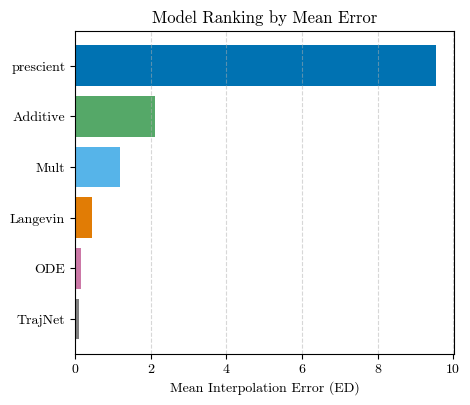

In [12]:
plt.subplot(1,1,1)
records = []

data = {
    'Langevin': intpl_err[0,:],
    'Mult': intpl_err[1,:],
    'Additive': intpl_err[2,:],
    'ODE': intpl_err[3,:],
    'prescient': intpl_err[4,:],
    'TrajNet': intpl_err[5,:]
}

for model, vals in data.items():
    for v in vals:
        records.append({'Model': model, 'Error': v})

colors = ['#E17C05', #'#E69F00',  # orange
          '#56B4E9',  # sky blue
          '#55A868', #'#009E73',  # bluish green
          '#CC78A7', #'#F0E442',  # yellow
          '#0072B2',  # blue
          '#7F7F7F'] #'#D55E00']  # vermillion

# Compute and sort by mean error
mean_errors = {model: np.mean(vals) for model, vals in data.items()}
sorted_items = sorted(mean_errors.items(), key=lambda x: x[1])  # ascending

models, means = zip(*sorted_items)
# Assign colors in sorted order
sorted_colors = [colors[i] for i in np.argsort(list(mean_errors.values()))]

bars = plt.barh(models, means, color=sorted_colors)
plt.xlabel('Mean Interpolation Error (ED)')
plt.title('Model Ranking by Mean Error')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.gcf().set_size_inches(4.5, 4)
# plt.savefig('results/exvivo_err.svg')

In [13]:
def simulate_inferred_extrapolation(drift_net, init_state, final_time, lx, nm, pert_flag=False, pert_ind=0):
    """
    Simulates dynamics from init_state to final_time using specified method.

    Parameters:
    -----------
    drift_net : torch.nn.Module- Trained drift model.
    init_state : torch.Tensor of shape (N, d+1), with last dim being time.
    final_time : float Time to simulate up to.
    lx : float Linear damping coefficient.
    nm : str  Method name: 'Langevin', 'Mult', 'Additive', 'ODE', 'pres', etc.
    pert_flag : bool If True, zero out a perturbed index during simulation.
    pert_ind : int Index to perturb if pert_flag is True.

    Returns:
    --------
    final_state : np.ndarray
        Simulated final state, shape (N, d)
    """
    drift_net.eval()
    inf_dt = 0.01
    Ndata, d_plus_1 = init_state.shape
    Ndim = d_plus_1 - 1

    Xold = init_state.clone().detach()

    while Xold[0, -1].item() < final_time:
        with torch.no_grad():
            if(nm=="Langevin" or nm=="Langevin_new"):
                drift = drift_net(Xold[:, :Ndim])
                noise = torch.sqrt(torch.relu(drift + lx * Xold[:, :Ndim])) * (inf_dt ** 0.5) * torch.randn_like(drift)
                Xnew = Xold.clone()
                Xnew[:, :Ndim] += (drift - lx * Xold[:, :Ndim]) * inf_dt + noise
            elif nm == "Mult":
                drift = drift_net(Xold[:, :Ndim])
                noise = torch.sqrt(torch.relu(Xold[:, :Ndim])) * (inf_dt ** 0.5) * torch.randn_like(drift)
                Xnew = Xold.clone()
                Xnew[:, :Ndim] += (drift - lx * Xold[:, :Ndim]) * inf_dt + noise

            elif nm == "Additive":
                drift = drift_net(Xold[:, :Ndim])
                noise = (inf_dt ** 0.5) * torch.randn_like(drift)
                Xnew = Xold.clone()
                Xnew[:, :Ndim] += (drift - lx * Xold[:, :Ndim]) * inf_dt + noise

            elif nm == "ODE":
                drift = drift_net(Xold[:, :Ndim])
                Xnew = Xold.clone()
                Xnew[:, :Ndim] += (drift - lx * Xold[:, :Ndim]) * inf_dt

            elif nm == "pres":
                noise = (2.0 ** 0.5) * (inf_dt ** 0.5) * torch.randn((Ndata, Ndim), device=Xold.device)
                with torch.enable_grad():
                    inp_ = Xold[:, :Ndim].clone().requires_grad_(True)
                    phi = drift_net(inp_)
                    grad_drift = gradient_field(phi, inp_)
                    Xnew = Xold.clone()
                    Xnew[:, :Ndim] += (-grad_drift - lx * inp_) * inf_dt + 0.1 * noise

            else:  # fallback: vanilla
                drift = drift_net(Xold[:, :])
                Xnew = Xold.clone()     
                Xnew[:, :Ndim] += 0*(drift - lx * Xold[:, :Ndim]) * inf_dt

        
            # Apply perturbation if required
            if pert_flag:
                Xnew[:, pert_ind] = 0;

                # print(" here ")
            # Clean up invalid states
            Xnew[:, :Ndim] = torch.where(torch.isnan(Xnew[:, :Ndim]) | (Xnew[:, :Ndim] < 0), 
                                         Xold[:, :Ndim], Xnew[:, :Ndim])
            Xnew[:, Ndim] += inf_dt
            Xold = Xnew

    return Xold[:, :Ndim].data.cpu().numpy()

In [14]:
device = 'cpu'

In [15]:
extpl_err = np.zeros((6, len(seed_list)))
base_path = "/mnt/ceph/users/smaddu/stochastic_inference"
gen_outputs_extpl = {model: {} for model in model_list}

for s_idx, seed in enumerate(seed_list):
    common_args = f"N6000_Ndim{Ndim}_Np{Np}_Nf{Nf}_fac4_seed{seed}"
    model_paths = {
        "Langevin_new":  f"{base_path}/fm_newset_fullspectral_exvivoHSPC_{common_args}_dmLangevin_new_lx{lx}_set{geneset_num}.path",
        "Mult":      f"{base_path}/fm_newset_fullspectral_exvivoHSPC_{common_args}_dmMult_lx{lx}_set{geneset_num}.path",
        "Additive":  f"{base_path}/fm_newset_fullspectral_exvivoHSPC_{common_args}_dmAdditive_lx{lx}_set{geneset_num}.path",
        "ODE":       f"{base_path}/fm_newset_fullspectral_exvivoHSPC_{common_args}_dmODE_lx{lx}_set{geneset_num}.path",
        "pres": f"{base_path}/fm_newset_fullspectral_prescient_exvivoHSPC_{common_args}_dmLangevin_lx{lx}_set{geneset_num}.path",
        "TrajNet":   f"{base_path}/fm_newset_fullspectral_TrajNet_exvivoHSPC_{common_args}_dmLangevin_lx{lx}_set{geneset_num}.path"
    }
    
    for m_idx, (model_name, model_path) in enumerate(model_paths.items()):
        print(model_name, model_path, seed)
        drift_net = torch.load(model_path,map_location='cpu',weights_only=False).eval()
        init = torch.tensor(np.zeros((HSC[::2,:].shape[0],Ndim+1)), dtype=torch.float32,device=device)
        init[:,0:Ndim] = torch.tensor(HSC[::2,0:Ndim],dtype=torch.float32,device=device) + 0;
        init[:,Ndim] = tp_test[0];
        gen_output = simulate_inferred_extrapolation(drift_net, init, tp_test[-1], lx, nm=model_name, pert_flag=False, pert_ind=1)
        gen_outputs_extpl[model_name][seed] = gen_output
        print(" done with ", model_name)

Langevin_new /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmLangevin_new_lx0.7_set7.path 0
 done with  Langevin_new
Mult /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmMult_lx0.7_set7.path 0
 done with  Mult
Additive /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmAdditive_lx0.7_set7.path 0
 done with  Additive
ODE /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmODE_lx0.7_set7.path 0
 done with  ODE
pres /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_prescient_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmLangevin_lx0.7_set7.path 0
 done with  pres
TrajNet /mnt/ceph/users/smaddu/stochastic_inference/fm_newset_fullspectral_TrajNet_exvivoHSPC_N6000_Ndim24_Np150_Nf150_fac4_seed0_dmLangevin_lx0.7_s

In [17]:
import sys
sys.path.insert(0,'/mnt/home/smaddu/anaconda3/lib/python3.9/site-packages')
import ot as pot

from torchcfm.optimal_transport import OTPlanSampler
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
ot_sampler = OTPlanSampler(method="exact")

In [29]:
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def plot_transition(ax, xk, xkp1, i_ind, inds, label, color, cmap_):

    mask = np.isin(i_ind, inds)
    # Extract and flatten matched samples
    all_xt = xk[mask]
    all_xtp1 = xkp1[mask]
    print(all_xt.shape, all_xtp1.shape)

    all_xt = all_xt.flatten()
    all_xtp1 = all_xtp1.flatten()
    
    hb = ax.hexbin(all_xt, all_xtp1, gridsize=10, cmap=cmap_, bins='log')
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('(count)')

    # Compute correlations
    rho, _ = spearmanr(all_xt, all_xtp1)
    r, _ = pearsonr(all_xt, all_xtp1)
    r2 =  torch.mean( (all_xt - all_xtp1)**2 )/torch.mean( all_xt**2 )
    #r2 =  r2_score(all_xt, all_xtp1)

    # Plot reference diagonal
    lim = [-0.5, 20]
    ax.plot(lim, lim, 'k--', lw=1)

    # Styling
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Experiment'); ax.set_ylabel('Model Prediction')
    ax.set_title(label)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Annotate correlations
    # ax.text(0.05, 0.95, f"Spearman  = {rho:.2f}\nPearson r = {r:.2f}",
    #         transform=ax.transAxes, ha='left', va='top', fontsize=11)
    ax.text(0.05, 0.95, rf"$\bf{{Spearman\ }}\rho = {rho:.2f}$" + "\n" + rf"$\bf{{Pearson\ }} r = {r:.2f}$" + "\n" + rf"$\bf{{RMSE\ }} = {r2:.2f}$",
         transform=ax.transAxes, ha='left', va='top', fontsize=12)

def compute_correlations(xk, xkp1, i_ind, inds):
    loss_fn = samples_loss.SamplesLoss("energy")

    mask = np.isin(i_ind, inds)
    all_xt = xk[mask]
    all_xtp1 = xkp1[mask]
    
    ED = loss_fn(torch.tensor(all_xt[0:5000,:],dtype=torch.float32), torch.tensor(all_xtp1[0:5000,:],dtype=torch.float32))

    all_xt    = all_xt.flatten()
    all_xtp1  = all_xtp1.flatten()
    
    rho, _ = spearmanr(all_xt, all_xtp1)
    r, _ = pearsonr(all_xt, all_xtp1)
    r2 =  torch.mean( (all_xt - all_xtp1)**2 )/torch.mean( all_xt**2 )  # mean_squared_error(all_xt, all_xtp1) #r2_score(all_xt, all_xtp1)

    return r**2, rho, ED, r2

### Correlation between data and prediction on train-set
### Load a model and see how the pearson correlation changes between train and test sets

(10483,) (10483,)
torch.Size([10483, 24]) torch.Size([10483, 24])
torch.Size([1544, 24]) torch.Size([1544, 24])
torch.Size([3427, 24]) torch.Size([3427, 24])


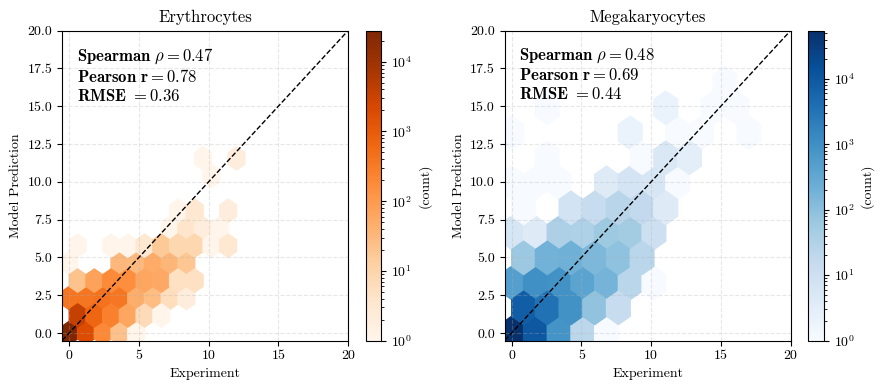

In [19]:
model_test = 'Langevin_new'; seed_ = 1;
pred_gen = torch.tensor(gen_outputs[model_test][seed_][-1,:,0:Ndim],dtype=torch.float32)
data_ = torch.tensor(samples[-1,:,0:Ndim],dtype=torch.float32)

pi = ot_sampler.get_map(data_, pred_gen) 
i_ind, j_ind = np.nonzero(pi)  # All nonzero transport pairs
print(i_ind.shape, j_ind.shape)

xk = data_[i_ind,:]; xkp1 = pred_gen[j_ind,:]
print(xk.shape, xkp1.shape)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_transition(axes[0], xk[:,], xkp1[:,], i_ind, ind_Ery, 'Erythrocytes', color='salmon', cmap_ = 'Oranges')
plot_transition(axes[1], xk[:,], xkp1[:,], i_ind, ind_Meg, 'Megakaryocytes', color='royalblue', cmap_ = 'Blues')

plt.tight_layout()

### Correlation between data and prediction on test-set

(10831,) (10831,)
torch.Size([1551, 24]) torch.Size([1551, 24])
torch.Size([3615, 24]) torch.Size([3615, 24])


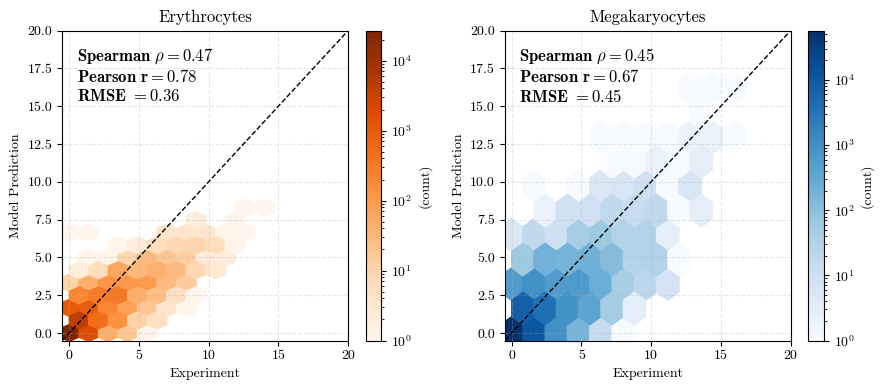

In [20]:
pred_gen = torch.tensor(gen_outputs_extpl[model_test][seed_][:,0:Ndim],dtype=torch.float32)
data_ = torch.tensor(samples[-1,:,0:Ndim],dtype=torch.float32)

pi = ot_sampler.get_map(data_, pred_gen) 
i_ind, j_ind = np.nonzero(pi)  # All nonzero transport pairs
print(i_ind.shape, j_ind.shape)

xk = data_[i_ind,:]; xkp1 = pred_gen[j_ind,:]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_transition(axes[0], xk[:,:], xkp1[:,:], i_ind, ind_Ery, 'Erythrocytes', color='salmon', cmap_ = 'Oranges')
plot_transition(axes[1], xk[:,:], xkp1[:,:], i_ind, ind_Meg, 'Megakaryocytes', color='royalblue', cmap_ = 'Blues')

plt.tight_layout()

### Reproducing the generalization plots in the paper

In [22]:
# --- Init storage ---
r_ery_train   = {model: np.zeros(len(seed_list)) for model in model_list}
r2_ery_train   = {model: np.zeros(len(seed_list)) for model in model_list}
rho_ery_train = {model: np.zeros(len(seed_list)) for model in model_list}
ED_ery_train = {model: np.zeros(len(seed_list)) for model in model_list}
r_meg_train   = {model: np.zeros(len(seed_list)) for model in model_list}
r2_meg_train   = {model: np.zeros(len(seed_list)) for model in model_list}
rho_meg_train = {model: np.zeros(len(seed_list)) for model in model_list}
ED_meg_train = {model: np.zeros(len(seed_list)) for model in model_list}

# --- Loop over models and seeds ---
for model in model_list:
    for i, seed in enumerate(seed_list):
        pred_gen = torch.tensor(gen_outputs[model][seed][-1, :, :Ndim], dtype=torch.float32)
        data_ = torch.tensor(samples[-1, :, :Ndim], dtype=torch.float32)
        
        pi = ot_sampler.get_map(data_, pred_gen) 
        i_ind, j_ind = np.nonzero(pi)

        xk = data_[i_ind, :]
        xkp1 = pred_gen[j_ind, :]

        r_ery, rho_ery, ED_ery, r2_ery = compute_correlations(xk, xkp1, i_ind, ind_Ery)
        r_meg, rho_meg, ED_meg, r2_meg = compute_correlations(xk, xkp1, i_ind, ind_Meg)

        r_ery_train[model][i]   = r_ery
        rho_ery_train[model][i] = rho_ery
        ED_ery_train[model][i] = ED_ery
        r2_ery_train[model][i] = r2_ery
        r_meg_train[model][i]   = r_meg
        rho_meg_train[model][i] = rho_meg
        ED_meg_train[model][i] = ED_meg
        r2_meg_train[model][i] = r2_meg

        print(f"[{model}] seed={seed} | r_ery={r_ery:.3f}, ρ_ery={rho_ery:.3f}, ED_ery={ED_ery:.3f}, r2_ery={r2_ery:.3f}, r_meg={r_meg:.3f}, ρ_meg={rho_meg:.3f}, ED_meg={ED_meg:.3f},  r2_meg={r2_meg:.3f}")

[Langevin_new] seed=0 | r_ery=0.568, ρ_ery=0.527, ED_ery=0.990, r2_ery=0.752, r_meg=0.455, ρ_meg=0.550, ED_meg=0.893,  r2_meg=0.617
[Langevin_new] seed=1 | r_ery=0.615, ρ_ery=0.470, ED_ery=0.360, r2_ery=0.362, r_meg=0.476, ρ_meg=0.483, ED_meg=0.574,  r2_meg=0.435
[Mult] seed=0 | r_ery=0.396, ρ_ery=0.443, ED_ery=1.974, r2_ery=1.515, r_meg=0.500, ρ_meg=0.584, ED_meg=1.315,  r2_meg=0.745
[Mult] seed=1 | r_ery=0.310, ρ_ery=0.391, ED_ery=2.650, r2_ery=2.293, r_meg=0.515, ρ_meg=0.548, ED_meg=2.152,  r2_meg=1.155
[Additive] seed=0 | r_ery=0.425, ρ_ery=0.515, ED_ery=4.389, r2_ery=3.017, r_meg=0.374, ρ_meg=0.589, ED_meg=3.710,  r2_meg=1.805
[Additive] seed=1 | r_ery=0.106, ρ_ery=0.335, ED_ery=3.847, r2_ery=3.734, r_meg=0.462, ρ_meg=0.646, ED_meg=2.930,  r2_meg=1.326
[ODE] seed=0 | r_ery=0.522, ρ_ery=0.460, ED_ery=0.307, r2_ery=0.458, r_meg=0.650, ρ_meg=0.618, ED_meg=0.065,  r2_meg=0.298
[ODE] seed=1 | r_ery=0.537, ρ_ery=0.450, ED_ery=0.309, r2_ery=0.430, r_meg=0.682, ρ_meg=0.619, ED_meg=0.070, 

In [23]:
xk.shape, xkp1.shape

(torch.Size([10999, 24]), torch.Size([10999, 24]))

In [24]:
# --- Init storage ---
r_ery_test   = {model: np.zeros(len(seed_list)) for model in model_list}
rho_ery_test = {model: np.zeros(len(seed_list)) for model in model_list}
r2_ery_test   = {model: np.zeros(len(seed_list)) for model in model_list}
ED_ery_test = {model: np.zeros(len(seed_list)) for model in model_list}
r_meg_test   = {model: np.zeros(len(seed_list)) for model in model_list}
rho_meg_test = {model: np.zeros(len(seed_list)) for model in model_list}
ED_meg_test = {model: np.zeros(len(seed_list)) for model in model_list}
r2_meg_test = {model: np.zeros(len(seed_list)) for model in model_list}

# --- Loop over models and seeds ---
for model in model_list:
    for i, seed in enumerate(seed_list):
        pred_gen = torch.tensor(gen_outputs_extpl[model][seed][:, :Ndim], dtype=torch.float32)
        data_ = torch.tensor(samples[-1, :, :Ndim], dtype=torch.float32)

        pi = ot_sampler.get_map(data_, pred_gen) 
        i_ind, j_ind = np.nonzero(pi)

        xk = data_[i_ind, :]
        xkp1 = pred_gen[j_ind, :]

        r_ery, rho_ery, ED_ery, r2_ery = compute_correlations(xk, xkp1, i_ind, ind_Ery)
        r_meg, rho_meg, ED_meg, r2_meg = compute_correlations(xk, xkp1, i_ind, ind_Meg)

        r_ery_test[model][i]   = r_ery
        rho_ery_test[model][i] = rho_ery
        ED_ery_test[model][i] = ED_ery
        r2_ery_test[model][i] = r2_ery
        r_meg_test[model][i]   = r_meg
        rho_meg_test[model][i] = rho_meg
        ED_meg_test[model][i] = ED_meg
        r2_meg_test[model][i] = r2_meg

        print(f"[{model}] seed={seed} | r_ery={r_ery:.3f}, ρ_ery={rho_ery:.3f}, ED_ery={ED_ery:.3f}, r2_ery={r2_ery:.3f}, r_meg={r_meg:.3f}, ρ_meg={rho_meg:.3f}, ED_meg={ED_meg:.3f},  r2_meg={r2_meg:.3f}")

[Langevin_new] seed=0 | r_ery=0.556, ρ_ery=0.527, ED_ery=0.920, r2_ery=0.719, r_meg=0.462, ρ_meg=0.561, ED_meg=0.822,  r2_meg=0.551
[Langevin_new] seed=1 | r_ery=0.604, ρ_ery=0.473, ED_ery=0.331, r2_ery=0.360, r_meg=0.455, ρ_meg=0.455, ED_meg=0.652,  r2_meg=0.449
[Mult] seed=0 | r_ery=0.400, ρ_ery=0.452, ED_ery=1.915, r2_ery=1.418, r_meg=0.481, ρ_meg=0.580, ED_meg=1.297,  r2_meg=0.725
[Mult] seed=1 | r_ery=0.318, ρ_ery=0.393, ED_ery=2.461, r2_ery=2.104, r_meg=0.522, ρ_meg=0.556, ED_meg=2.107,  r2_meg=1.131
[Additive] seed=0 | r_ery=0.412, ρ_ery=0.508, ED_ery=4.356, r2_ery=3.083, r_meg=0.373, ρ_meg=0.588, ED_meg=3.722,  r2_meg=1.813
[Additive] seed=1 | r_ery=0.118, ρ_ery=0.341, ED_ery=3.634, r2_ery=3.411, r_meg=0.471, ρ_meg=0.646, ED_meg=2.732,  r2_meg=1.253
[ODE] seed=0 | r_ery=0.210, ρ_ery=0.430, ED_ery=2.593, r2_ery=2.928, r_meg=0.384, ρ_meg=0.574, ED_meg=2.292,  r2_meg=1.581
[ODE] seed=1 | r_ery=0.219, ρ_ery=0.436, ED_ery=2.642, r2_ery=2.780, r_meg=0.347, ρ_meg=0.542, ED_meg=2.218, 

In [25]:
def stylish_metric_plot_xy(train_dict, test_dict, min_lim=0, max_lim=1.0, metric='Pearson', celltype='Erythroid', stat_name='Pearson $r$'):

    exclude_models = {'pres','Langevin'}  # Add more model names to skip if needed
    
    """
    Scatter plot of Train vs Test metrics with mean±std shown for each model.
    """
    model_list = list(train_dict.keys())

    colors = ['red',  # orange
              '#E69F00',
          '#56B4E9',  # sky blue
          '#009E73',  # bluish green
          '#F0E442',  # yellow
          '#0072B2',  # blue
          '#D55E00']  # vermillion
    
    # Define colors and markers
   # colors = ['#D55E00', '#0072B2', '#009E73', '#CC79A7', '#E69F00', '#56B4E9']
    markers = ['o', 'o', 's', '^', 'd', 'v', 'P']

    
    plt.figure(figsize=(5, 5))
    
    for i, model in enumerate(model_list):
        if model in exclude_models:
            continue  # skip this model
        train_vals = np.sqrt(np.array(train_dict[model]))
        test_vals = np.sqrt(np.array(test_dict[model]))

        # Compute means and stds
        x_mean, x_std = np.mean(train_vals), np.std(train_vals)
        y_mean, y_std = np.mean(test_vals), np.std(test_vals)

        plt.errorbar(x_mean, y_mean, xerr=x_std, yerr=y_std, 
                     fmt=markers[i], markersize=15, 
                     label=model, 
                     color=colors[i], capsize=4, elinewidth=1.2, markeredgecolor='black')

    # Reference line (ideal generalization)
    lims = [min_lim, max_lim]
    plt.plot(lims, lims, 'k--', lw=1)
    #plt.xlim(lims)
    #plt.ylim(lims)
    
    plt.xlabel(f'HSC initial condition \n (Training) ', fontsize=16)
    plt.ylabel(f'HSPC initial condition \n (Testing)', fontsize=16)
    plt.title(celltype, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='best', frameon=True, fontsize=16)
    plt.tight_layout()
    # plt.savefig(f'results/exvivo_{metric}_xy_{celltype}.svg')
    plt.show()

In [26]:
model_list

['Langevin_new', 'Mult', 'Additive', 'ODE', 'pres', 'TrajNet']

### Plots and results in the paper
### The best method should line on the dashed line.. towards the top right corner

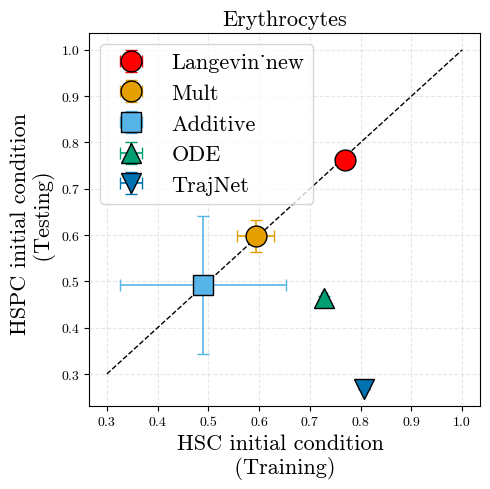

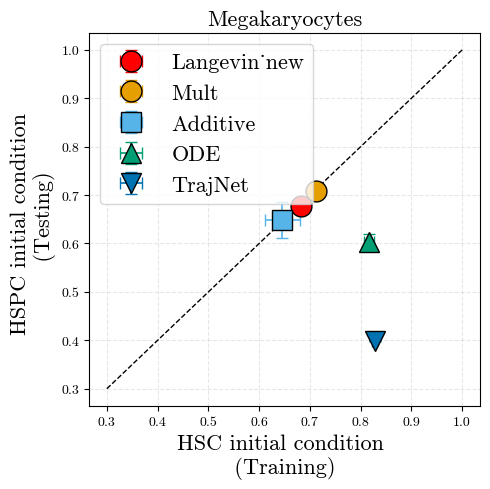

In [27]:
stylish_metric_plot_xy(r_ery_train, r_ery_test, 0.3,1.0, metric='Pearson', celltype='Erythrocytes', stat_name='Pearson correlation ($r$)')
stylish_metric_plot_xy(r_meg_train, r_meg_test, 0.3,1.0, metric='Pearson', celltype='Megakaryocytes', stat_name='Pearson correlation ($r$)')

### Generalization results based on $L_2$ distance between the gene expression prediction and observation
### The best method should line on the dashed line.. towards the bottom left corner

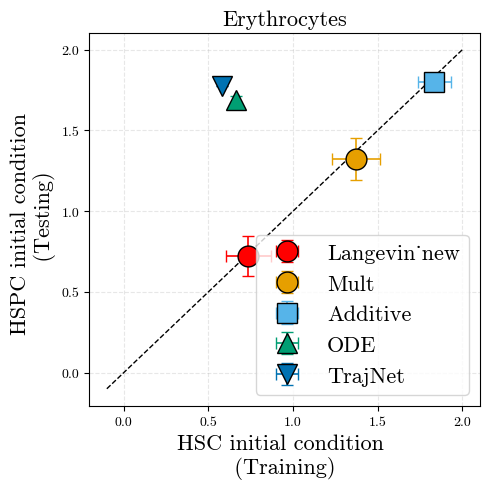

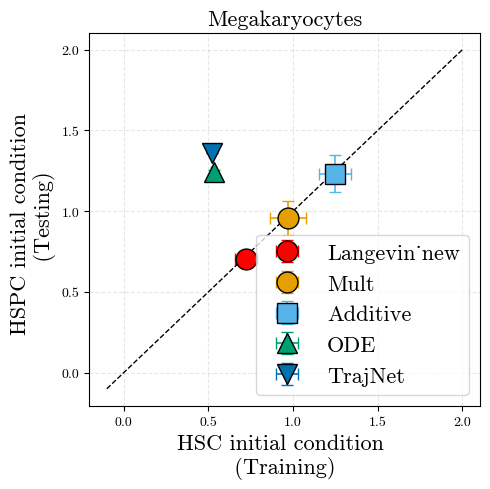

In [28]:
stylish_metric_plot_xy(r2_ery_train, r2_ery_test, -0.1,2.0, metric='RMSE', celltype='Erythrocytes', stat_name='RMSE')
stylish_metric_plot_xy(r2_meg_train, r2_meg_test, -0.1,2.0, metric='RMSE', celltype='Megakaryocytes', stat_name='RMSE')